# Radio Synchrotron Modelling Analysis

This is a separate notebook just so I don't have to keep rerunning the chains when they look fine

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo

from corner import corner

import syncfit

from otter import Otter

private_data_path = "private_otter_data"
db = Otter(
    url="http://localhost:8529",
    username="root",
    password="",
    datadir=private_data_path,
    gen_summary=True
)

In [2]:
def get_bounds(chain, ndim=3):
    
    medians, upper, lower = [], [], []
    for i in range(ndim):
        mcmc = np.percentile(chain[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        vals = [mcmc[1],(q[0]+q[1])/2]

        medians.append(mcmc[1])
        upper.append(q[1])
        lower.append(q[0])

    return medians, upper, lower


In [3]:
labels = ["p", 'log_F_nu', 'log_nu_a']

best_fit_params = dict(
    name = [],
    mjd = [],
    p = [],
    p_up = [],
    p_lo = [],
    log_F_nu = [],
    log_F_nu_up = [],
    log_F_nu_lo = [],
    log_nu_a = [],
    log_nu_a_up = [],
    log_nu_a_lo = []
)

for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):

    with open(jfile, "r") as j:
        chain_dict = json.load(j)
    
    tname = jfile.split('-')[1].split('/')[1]

    print(tname)

    for k, chain in chain_dict.items():
        medians, uplims, lowlims = get_bounds(np.array(chain))
        print(f"\tMJD = {k}")
        for median, uplim, lowlim, lab in zip(medians, uplims, lowlims, labels):
            print(f"\t\t${lab} = {median:.2f}^+{uplim:.2f}_-{lowlim:.2f}$")

            best_fit_params[lab].append(median)
            best_fit_params[f"{lab}_up"].append(uplim)
            best_fit_params[f"{lab}_lo"].append(lowlim)
        best_fit_params["mjd"].append(k)
        best_fit_params["name"].append(tname)
        
        
    
    print()

res = pd.DataFrame(best_fit_params)

SDSSJ1241
	MJD = 57629.5
		$p = 3.57^+0.21_-0.35$
		$log_F_nu = 1.35^+0.45_-0.37$
		$log_nu_a = 8.74^+0.37_-0.38$
	MJD = 57959.0
		$p = 3.88^+0.09_-0.52$
		$log_F_nu = 1.18^+0.03_-0.04$
		$log_nu_a = 8.98^+0.02_-0.14$
	MJD = 58754.0
		$p = 3.96^+0.03_-0.64$
		$log_F_nu = 0.91^+0.02_-0.03$
		$log_nu_a = 9.01^+0.01_-0.19$
	MJD = 59050.0
		$p = 2.29^+0.23_-0.13$
		$log_F_nu = 1.24^+0.51_-0.56$
		$log_nu_a = 7.58^+0.90_-0.84$
	MJD = 59500.0
		$p = 3.65^+0.26_-0.58$
		$log_F_nu = 1.40^+0.43_-0.60$
		$log_nu_a = 8.44^+0.42_-0.34$

SDSSJ0938
	MJD = 57459.0
		$p = 3.19^+0.37_-0.40$
		$log_F_nu = 1.12^+0.61_-0.46$
		$log_nu_a = 8.65^+0.56_-0.61$
	MJD = 57912.0
		$p = 3.09^+0.16_-0.14$
		$log_F_nu = 1.20^+0.53_-0.24$
		$log_nu_a = 8.44^+0.33_-0.57$

SDSSJ0748
	MJD = 57458.0
		$p = 2.81^+0.63_-0.48$
		$log_F_nu = 0.50^+0.97_-0.84$
		$log_nu_a = 8.15^+1.04_-1.16$
	MJD = 57914.0
		$p = 2.60^+0.45_-0.29$
		$log_F_nu = 0.38^+0.92_-0.73$
		$log_nu_a = 7.73^+1.04_-1.12$



In [4]:
# add in other information we need about each object

redshift = dict(
    SDSSJ1241 = db.get_meta(names="SDSS_J1241", query_private=True)[0].get_redshift(),
    SDSSJ0938 = db.get_meta(names="SDSS_J0938", query_private=True)[0].get_redshift(),
    SDSSJ0748 = db.get_meta(names="SDSS_J0748", query_private=True)[0].get_redshift()
)

disc_date = dict(
    SDSSJ1241 = db.get_meta(names="SDSS_J1241", query_private=True)[0].get_discovery_date().mjd,
    SDSSJ0938 = db.get_meta(names="SDSS_J0938", query_private=True)[0].get_discovery_date().mjd,
    SDSSJ0748 = db.get_meta(names="SDSS_J0748", query_private=True)[0].get_discovery_date().mjd
)

lum_dist = dict(
    SDSSJ1241 = None,
    SDSSJ0938 = None,
    SDSSJ0748 = None
)

for name, z in redshift.items():
    lum_dist[name] = cosmo.luminosity_distance(z).to("cm").value

res['z'] = res.name.map(redshift).astype(float)
res["lum_dist"] = res.name.map(lum_dist).astype(float)
res["disc_date"] = res.name.map(disc_date).astype(float)

res["dt"] = res.mjd.astype(float) - res.disc_date

res

/home/noahf/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


,name,mjd,p,p_up,p_lo,log_F_nu,log_F_nu_up,log_F_nu_lo,log_nu_a,log_nu_a_up,log_nu_a_lo,z,lum_dist,disc_date,dt
0,SDSSJ1241,57629.5,3.571883,0.207684,0.352500,1.348285,0.445148,0.365717,8.743547,0.368730,0.384122,0.0419,5.909865e+26,53062.0,4567.5
1,SDSSJ1241,57959.0,3.884762,0.087517,0.516807,1.176276,0.027493,0.037829,8.981878,0.020644,0.144287,0.0419,5.909865e+26,53062.0,4897.0
2,SDSSJ1241,58754.0,3.962760,0.032184,0.638261,0.906718,0.023966,0.033516,9.014308,0.013530,0.188532,0.0419,5.909865e+26,53062.0,5692.0
3,SDSSJ1241,59050.0,2.286125,0.227027,0.131538,1.236303,0.508405,0.563423,7.576586,0.902605,0.836733,0.0419,5.909865e+26,53062.0,5988.0
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,1.400793,0.433374,0.601798,8.437228,0.420560,0.343002,0.0419,5.909865e+26,53062.0,6438.0
5,SDSSJ0938,57459.0,3.194251,0.371804,0.404643,1.121971,0.605158,0.455933,8.652002,0.557054,0.610101,0.1010,1.483898e+27,54092.0,3367.0
6,SDSSJ0938,57912.0,3.086663,0.157781,0.135965,1.198764,0.534909,0.238301,8.436692,0.328855,0.571719,0.1010,1.483898e+27,54092.0,3820.0
7,SDSSJ0748,57458.0,2.805552,0.631945,0.479167,0.496527,0.965694,0.839391,8.147339,1.037700,1.156877,0.0615,8.795978e+26,52935.0,4523.0
8,SDSSJ0748,57914.0,2.600990,0.445123,0.286097,0.378762,0.921655,0.731863,7.727498,1.040126,1.119539,0.0615,8.795978e+26,52935.0,4979.0


In [5]:
def _mini_converter(d_L, nu_p):
    '''
    Converts to the appropriate units for the paper
    '''
    return d_L/1e28, nu_p/1e10

def Req(p, F_p_mJy, nu_p, z, d_L, chi_e=1, gamma=2, f_V=1, f_A=1):
    """
    Barniol Duran Eq. 27
    """

    d_L, nu_p = _mini_converter(d_L, nu_p)

    prefactor = 1e17 * (21.8 * 525**(p-1))**(1/(13+2*p)) * chi_e**((2-p)/(13+2*p))
    midfactor = F_p_mJy**((6+p)/(13+2*p)) * d_L**((2*(p+6))/(13+2*p)) * nu_p**(-1) * (1+z)**-((19+3*p)/(13+2*p)) 
    postfactor= f_A**-((5+p)/(13+2*p)) * f_V**-(1/(13+2*p)) * gamma**((p+8)/(13+2*p)) * (gamma-1)**((2-p)/(13+2*p))
    
    return prefactor * midfactor * postfactor

def Eeq(p, F_p_mJy, nu_p, z, d_L, chi_e=1, gamma=2, f_V=1, f_A=1):
    """
    Barniol Duran Eq. 28 
    """

    d_L, nu_p = _mini_converter(d_L, nu_p)

    prefactor = 1.3e48 * 21.8**-(2*(p+1)/(13+2*p)) * (525**(p-1) * chi_e**(2-p))**(11/(13+2*p))
    midfactor = F_p_mJy**((14+3*p)/(13+2*p)) * d_L**(2*(3*p+14)/(13+2*p)) * nu_p**(-1) * (1+z)**-((27+5*p)/(13+2*p))
    postfactor= f_A**(-3*(p+1)/(13+2*p)) * f_V**(2*(p+1)/(13+2*p)) * gamma**-((5*p+16)/(13+2*p)) * (gamma-1)**(-11*(p-2)/(13+2*p))

    return prefactor * midfactor * postfactor

### Bootstrap this calculation to propagate uncertainties

In [6]:
from functools import partial
from copy import deepcopy
from tqdm.notebook import tqdm, trange

# first bootstrap the calculations of Eeq and Req
n_sample = int(1e3)
n_bootstrap = int(1e3)

stat_method = np.median # or np.mean
stat_method_err = partial(np.percentile, q=[25,75]) # or np.std

gammas = range(2,10)
result_dfs = []
for gamma in gammas:
    res = deepcopy(res)
    
    Req_res, Eeq_res = [], []
    Req_err, Eeq_err = [], []
    for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):
    
        with open(jfile, "r") as j:
            chain_dict = json.load(j)
        
        tname = jfile.split('-')[1].split('/')[1]
    
        print(f"Starting {tname} w/ Gamma={gamma}...")
    
        z = float(redshift[tname])
        lum_dist_val = float(lum_dist[tname])
    
        for k, chain in chain_dict.items():
            means = np.array(
                [
                    [
                        stat_method(np.random.choice(v, n_sample)) 
                        for v in np.array(chain).T
                    ] 
                    for _ in range(n_bootstrap)
                ]
            )
    
            # now calculate the Req and Eeq from means
            means = np.array(means)
            Req_vals = Req(means[:,0], 10**means[:,1], 10**means[:,2], z, lum_dist_val, gamma=gamma)
            Eeq_vals = Eeq(means[:,0], 10**means[:,1], 10**means[:,2], z, lum_dist_val, gamma=gamma)
    
            Req_res_mid = stat_method(Req_vals)
            Req_res.append(Req_res_mid)
    
            Eeq_res_mid = stat_method(Eeq_vals)
            Eeq_res.append(Eeq_res_mid)
    
            
            Req_err_val = stat_method_err(Req_vals)
            if not isinstance(Req_err_val, (list, np.ndarray)):
                Req_err_val = [Req_err_val, Req_err_val]
            else:
                Req_err_val = [
                    Req_res_mid-Req_err_val[0],
                    Req_err_val[1]-Req_res_mid
                ]
                
            Eeq_err_val = stat_method_err(Eeq_vals)
            if not isinstance(Eeq_err_val, (list, np.ndarray)):
                Eeq_err_val = [Eeq_err_val, Eeq_err_val]
            else:
                Eeq_err_val = [
                    Eeq_res_mid-Eeq_err_val[0],
                    Eeq_err_val[1]-Eeq_res_mid
                ]
            
            Req_err.append(Req_err_val)
            Eeq_err.append(Eeq_err_val)
    
        print(f"Finished {tname} w/ Gamma={gamma}!")

    res["Req"] = Req_res
    res["Eeq"] = Eeq_res
    res["Req_up"] = np.array(Req_err)[:,1]
    res["Eeq_up"] = np.array(Eeq_err)[:,0]
    res["Req_lo"] = np.array(Req_err)[:,1]
    res["Eeq_lo"] = np.array(Eeq_err)[:,0]
    res["Gamma"] = gamma

    result_dfs.append(res)

result_df = pd.concat(result_dfs)

# this takes a while to run so let's save the results
result_df.to_csv(f"bootstrap-result-{len(list(gammas))}nGamma-{n_bootstrap}nBootstrap.csv")

result_df

Starting SDSSJ1241 w/ Gamma=2...
Finished SDSSJ1241 w/ Gamma=2!
Starting SDSSJ0938 w/ Gamma=2...
Finished SDSSJ0938 w/ Gamma=2!
Starting SDSSJ0748 w/ Gamma=2...
Finished SDSSJ0748 w/ Gamma=2!
Starting SDSSJ1241 w/ Gamma=3...
Finished SDSSJ1241 w/ Gamma=3!
Starting SDSSJ0938 w/ Gamma=3...
Finished SDSSJ0938 w/ Gamma=3!
Starting SDSSJ0748 w/ Gamma=3...
Finished SDSSJ0748 w/ Gamma=3!
Starting SDSSJ1241 w/ Gamma=4...
Finished SDSSJ1241 w/ Gamma=4!
Starting SDSSJ0938 w/ Gamma=4...
Finished SDSSJ0938 w/ Gamma=4!
Starting SDSSJ0748 w/ Gamma=4...
Finished SDSSJ0748 w/ Gamma=4!
Starting SDSSJ1241 w/ Gamma=5...
Finished SDSSJ1241 w/ Gamma=5!
Starting SDSSJ0938 w/ Gamma=5...
Finished SDSSJ0938 w/ Gamma=5!
Starting SDSSJ0748 w/ Gamma=5...
Finished SDSSJ0748 w/ Gamma=5!
Starting SDSSJ1241 w/ Gamma=6...
Finished SDSSJ1241 w/ Gamma=6!
Starting SDSSJ0938 w/ Gamma=6...
Finished SDSSJ0938 w/ Gamma=6!
Starting SDSSJ0748 w/ Gamma=6...
Finished SDSSJ0748 w/ Gamma=6!
Starting SDSSJ1241 w/ Gamma=7...
Finishe

,name,mjd,p,p_up,p_lo,log_F_nu,log_F_nu_up,log_F_nu_lo,log_nu_a,log_nu_a_up,...,lum_dist,disc_date,dt,Req,Eeq,Req_up,Eeq_up,Req_lo,Eeq_lo,Gamma
0,SDSSJ1241,57629.5,3.571883,0.207684,0.352500,1.348285,0.445148,0.365717,8.743547,0.368730,...,5.909865e+26,53062.0,4567.5,1.946271e+18,4.741961e+50,5.656535e+16,2.042845e+49,5.656535e+16,2.042845e+49,2
1,SDSSJ1241,57959.0,3.884762,0.087517,0.516807,1.176276,0.027493,0.037829,8.981878,0.020644,...,5.909865e+26,53062.0,4897.0,9.928423e+17,3.337076e+50,2.049322e+15,2.660845e+48,2.049322e+15,2.660845e+48,2
2,SDSSJ1241,58754.0,3.962760,0.032184,0.638261,0.906718,0.023966,0.033516,9.014308,0.013530,...,5.909865e+26,53062.0,5692.0,6.958705e+17,1.692058e+50,8.442431e+14,7.042120e+47,8.442431e+14,7.042120e+47,2
3,SDSSJ1241,59050.0,2.286125,0.227027,0.131538,1.236303,0.508405,0.563423,7.576586,0.902605,...,5.909865e+26,53062.0,5988.0,1.868734e+19,1.842729e+50,1.176259e+18,1.344514e+49,1.176259e+18,1.344514e+49,2
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,1.400793,0.433374,0.601798,8.437228,0.420560,...,5.909865e+26,53062.0,6438.0,4.224422e+18,1.311427e+51,1.275262e+17,6.895101e+49,1.275262e+17,6.895101e+49,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,SDSSJ1241,59500.0,3.646321,0.263945,0.577098,1.400793,0.433374,0.601798,8.437228,0.420560,...,5.909865e+26,53062.0,6438.0,8.496178e+18,1.639719e+49,2.568436e+17,8.360627e+47,2.568436e+17,8.360627e+47,9
5,SDSSJ0938,57459.0,3.194251,0.371804,0.404643,1.121971,0.605158,0.455933,8.652002,0.557054,...,1.483898e+27,54092.0,3367.0,8.041055e+18,2.187529e+49,3.996708e+17,1.400738e+48,3.996708e+17,1.400738e+48,9
6,SDSSJ0938,57912.0,3.086663,0.157781,0.135965,1.198764,0.534909,0.238301,8.436692,0.328855,...,1.483898e+27,54092.0,3820.0,1.408134e+19,3.841587e+49,5.536144e+17,1.838842e+48,5.536144e+17,1.838842e+48,9
7,SDSSJ0748,57458.0,2.805552,0.631945,0.479167,0.496527,0.965694,0.839391,8.147339,1.037700,...,8.795978e+26,52935.0,4523.0,7.931532e+18,2.212924e+48,5.789465e+17,2.224083e+47,5.789465e+17,2.224083e+47,9


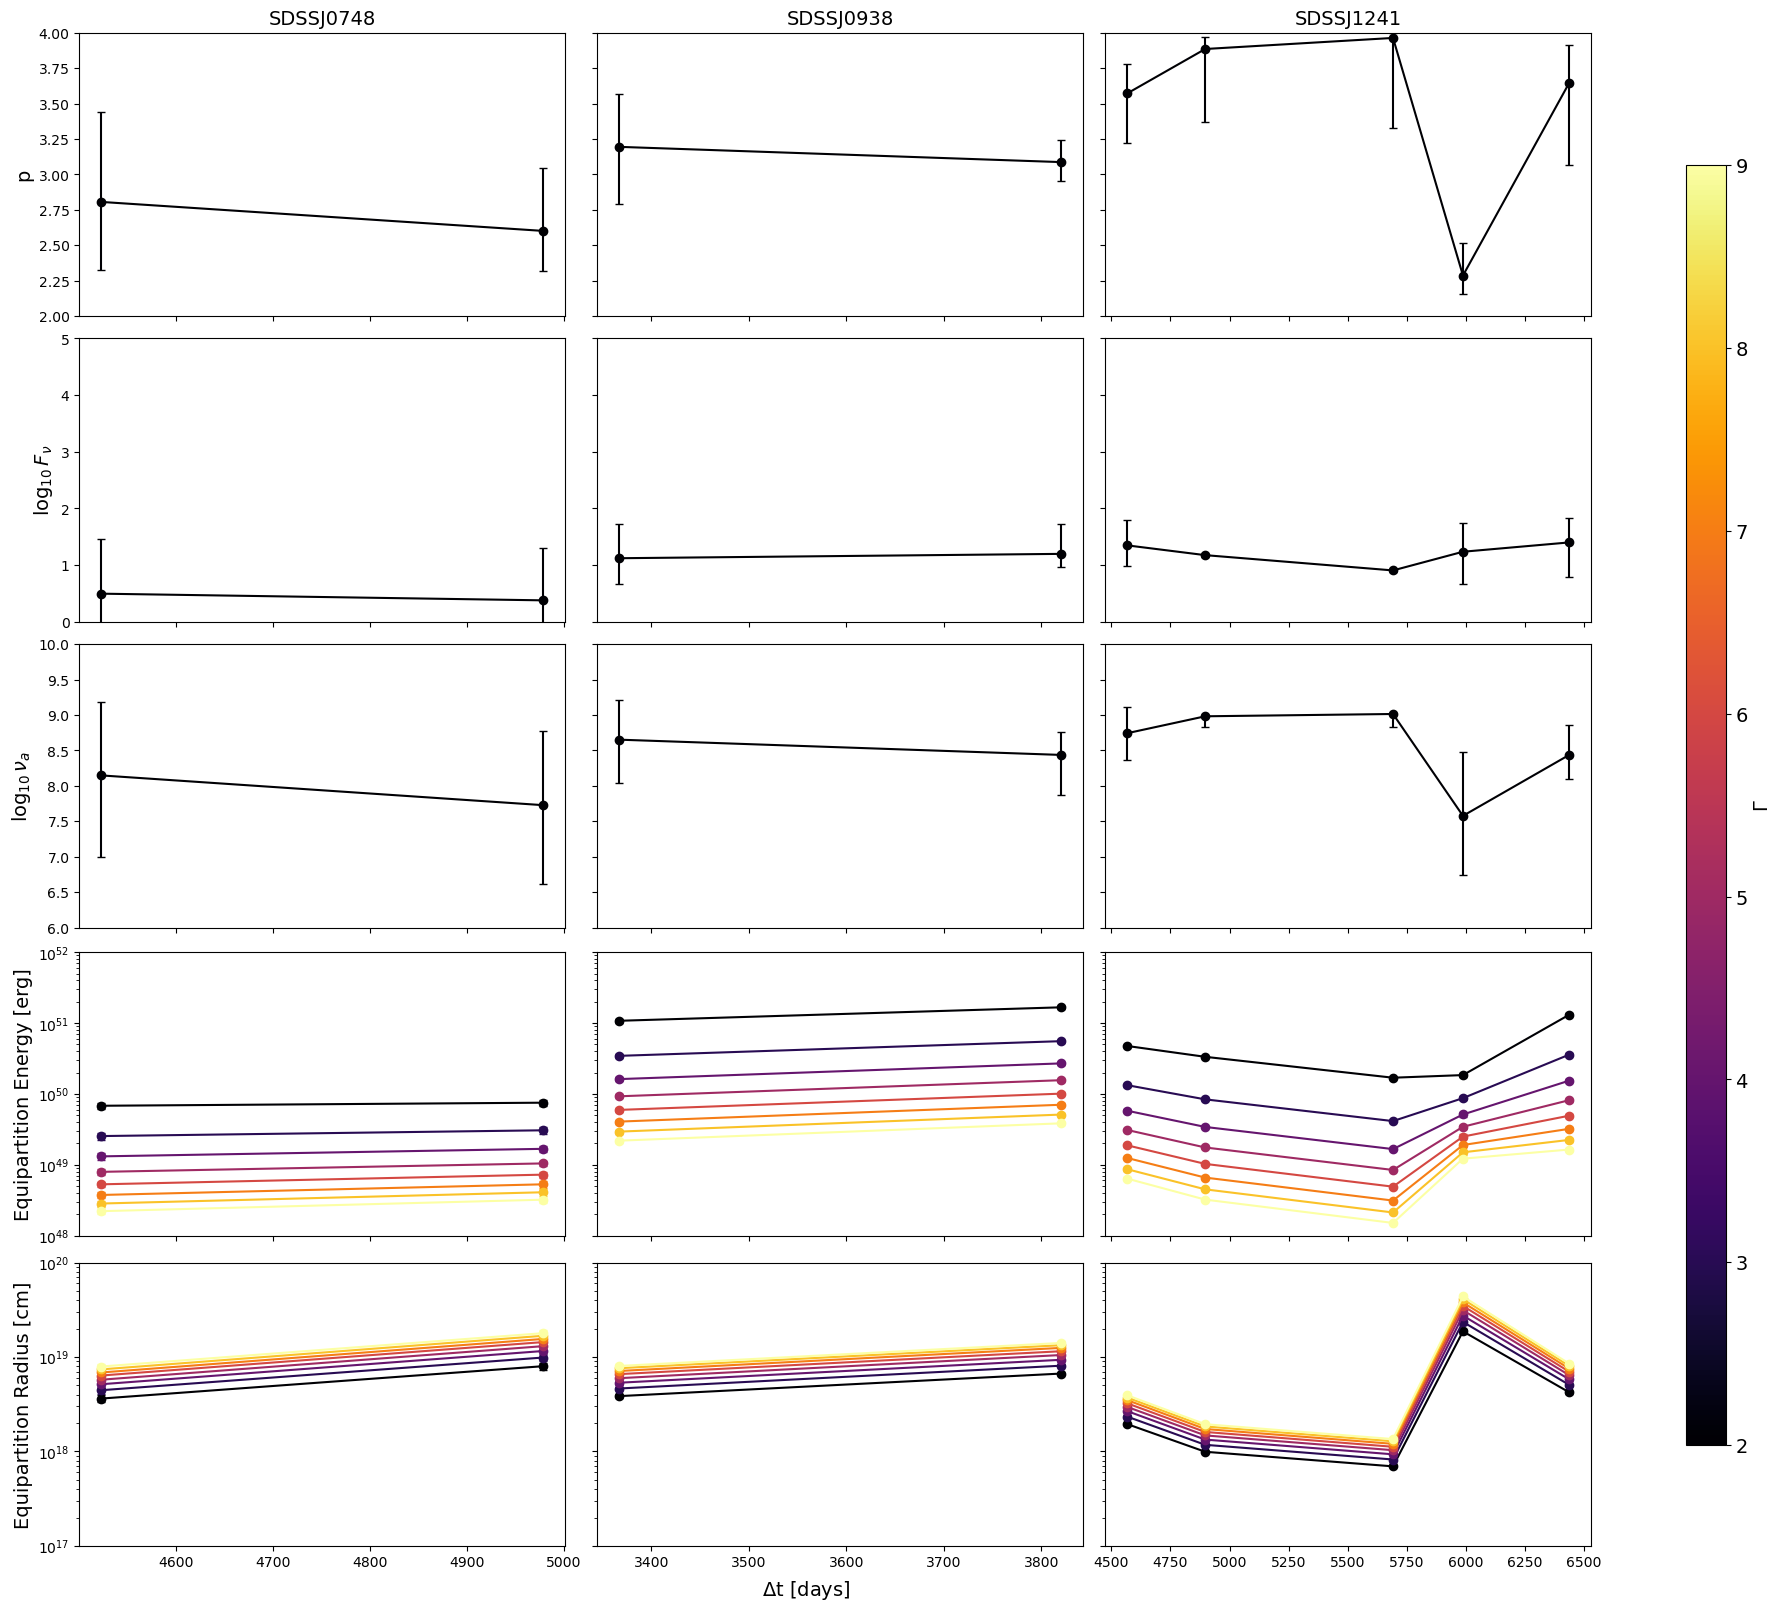

In [10]:
fig, axs = plt.subplots(5,3, sharex="col", sharey="row", figsize=(16,16), layout="constrained")


keys = {
    "p" : "p",
    "log_F_nu": r"$\log_{10} F_{\nu}$",
    "log_nu_a": r"$\log_{10} \nu_a$",
    "Eeq" : "Equipartition Energy [erg]",
    "Req" : "Equipartition Radius [cm]",
    # "Gamma" : r"$\Gamma$"
}

ranges = {
    "Eeq" : (1e48, 1e52),
    "Req" : (1e17, 1e20),
    "p": (2,4),
    "log_F_nu": (0,5),
    "log_nu_a": (6,10)
    # "Gamma" : (1e1, 1e3)
}

colorbar_keys = {"Eeq", "Req"}

gammas = result_df.Gamma.unique()
n_lines = len(list(gammas))
cmap = mpl.colormaps['inferno']
colors = cmap(np.linspace(0,1,n_lines))

xvar = "dt"

label_fs = 14

for jj, (c, (gamma, df)) in enumerate(zip(colors, result_df.groupby("Gamma"))):
    for ii, (ax1d, (key, label)) in enumerate(zip(axs, keys.items())):
        ax1d[0].set_ylabel(label, fontsize=label_fs)
        for ax, (name, grp) in zip(ax1d, df.groupby("name")):
            if key in colorbar_keys:
                cplot = c
            elif jj > 0:
                continue # we can skip these keys the 2nd-nth time
            else:
                cplot = 'k'
            
            ax.errorbar(
                grp[xvar], 
                grp[key], 
                yerr=(grp[key+"_lo"], grp[key+"_up"]), 
                marker='o', 
                linestyle='-', 
                color=c,
                capsize=3
            )
            if not ii:
                ax.set_title(f"{name}", fontsize=label_fs)
    
            ax.set_ylim(*ranges[key])
            # ax.set_xscale("log")

axs[-1][0].set_yscale("log")
axs[-2][0].set_yscale("log")

cax = plt.axes((1.05, 0.1, 0.025, 0.8))
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=None), 
    cax=cax,
    ticks=np.linspace(0, 1, len(gammas)),
)
cbar.ax.set_ylabel(r"$\Gamma$", fontsize=label_fs)
cbar.ax.set_yticklabels(list(gammas), fontsize=label_fs)

fig.supxlabel(r"$\Delta$t [days]", fontsize=label_fs)

fig.savefig("equipartition-results-bootstrap.png", bbox_inches="tight")